# Week 2 — Flower Classifier & House Price Predictor

**Theme:** Supervised learning I — k-nearest neighbors & linear regression

Supervised learning means: we have labeled examples (input -> correct answer),
and we want the computer to learn the pattern well enough to predict the answer
for *new*, unseen inputs. There are two flavors:

- **Classification** — the answer is a category (e.g. which species of flower,
  benign vs. malignant)
- **Regression** — the answer is a number (e.g. a price, a score)

**k-Nearest Neighbors (k-NN)** is the simplest way to do either: to predict a
new example, find its `k` closest neighbors among the examples we already
know the answer for, then **vote** (classification) or **average**
(regression). We'll try it on three datasets — two classification, one
regression — then move on to linear regression.

In [304]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris, load_breast_cancer, fetch_california_housing, load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso, RidgeCV, LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, mean_squared_error, r2_score

## Part A — k-Nearest Neighbors (Classification & Regression)

세 가지 데이터셋으로 연습합니다: **Iris**(품종 분류), **Breast Cancer**(양성/
악성 분류), **California Housing**(주택 가격 회귀). 먼저 각각 `k=1`로 기본
흐름 — **데이터 나누기 → 모델 만들기(메서드 호출) → 학습 → 평가** — 을
살펴봅니다.

### 1. Iris — 꽃 품종 분류

150개 꽃, 4개 측정값(꽃받침/꽃잎 길이·너비), 3개 품종.

In [305]:
iris = load_iris()
X_iris, y_iris = iris.data, iris.target
print("Features:", iris.feature_names)
print("Species:", iris.target_names)
print("Shape:", X_iris.shape)

Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Species: ['setosa' 'versicolor' 'virginica']
Shape: (150, 4)


In [306]:
# 데이터 나누기: 학습용 vs 테스트용 (테스트 데이터는 절대 학습에 쓰지 않습니다)
X_iris_train, X_iris_test, y_iris_train, y_iris_test = train_test_split(
    X_iris, y_iris, test_size=0.3, random_state=42, stratify=y_iris
)

# 모델 만들기(메서드 호출) -> 학습 -> 평가, 우선 k=1부터 시작해봅니다
knn_iris = KNeighborsClassifier(n_neighbors=1)
knn_iris.fit(X_iris_train, y_iris_train)

predictions = knn_iris.predict(X_iris_test)
accuracy = accuracy_score(y_iris_test, predictions)
print(f"Test accuracy with k=1: {accuracy:.2%}")

Test accuracy with k=1: 93.33%


**참고:** 아래는 4개 측정값 중 2개(꽃잎 길이/너비)만 써서 k-NN이 실제로
공간을 어떻게 나누는지 시각화한 것입니다 (부드러운 경계를 보여주기 위해
`k=5`로 그렸습니다 — 위 `k=1`보다 경계가 훨씬 덜 들쭉날쭉합니다).

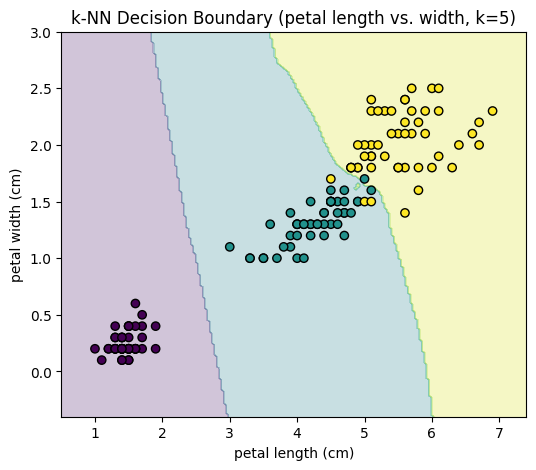

In [307]:
X_iris2 = X_iris[:, 2:4]  # petal length, petal width
X_iris2_train, X_iris2_test, y_iris2_train, y_iris2_test = train_test_split(
    X_iris2, y_iris, test_size=0.3, random_state=42, stratify=y_iris
)
knn_iris2 = KNeighborsClassifier(n_neighbors=5).fit(X_iris2_train, y_iris2_train)

xx, yy = np.meshgrid(
    np.linspace(X_iris2[:, 0].min() - 0.5, X_iris2[:, 0].max() + 0.5, 200),
    np.linspace(X_iris2[:, 1].min() - 0.5, X_iris2[:, 1].max() + 0.5, 200),
)
Z = knn_iris2.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(6, 5))
plt.contourf(xx, yy, Z, alpha=0.25, cmap="viridis")
plt.scatter(X_iris2[:, 0], X_iris2[:, 1], c=y_iris, cmap="viridis", edgecolor="k")
plt.title("k-NN Decision Boundary (petal length vs. width, k=5)")
plt.xlabel(iris.feature_names[2])
plt.ylabel(iris.feature_names[3])
plt.show()

### 2. Breast Cancer — 양성/악성 분류

569개 종양 샘플, 30개 측정값(세포 크기, 질감 등), 2개 클래스
(malignant/benign).

In [308]:
cancer = load_breast_cancer()
X_cancer, y_cancer = cancer.data, cancer.target
print("Features:", len(cancer.feature_names))
print("Classes:", list(cancer.target_names))
print("Shape:", X_cancer.shape)

Features: 30
Classes: [np.str_('malignant'), np.str_('benign')]
Shape: (569, 30)


In [309]:
X_cancer_train, X_cancer_test, y_cancer_train, y_cancer_test = train_test_split(
    X_cancer, y_cancer, test_size=0.3, random_state=42, stratify=y_cancer
)

knn_cancer = KNeighborsClassifier(n_neighbors=1)
knn_cancer.fit(X_cancer_train, y_cancer_train)

predictions = knn_cancer.predict(X_cancer_test)
accuracy = accuracy_score(y_cancer_test, predictions)
print(f"Test accuracy with k=1: {accuracy:.2%}")

Test accuracy with k=1: 92.40%


### 3. California Housing — 주택 가격 회귀

k-NN은 회귀에도 쓸 수 있습니다 — 다수결 투표 대신, 가장 가까운 `k`개
이웃의 **타깃값을 평균**냅니다. 20,640개 캘리포니아 지역구, 8개 특징
(소득, 방 개수, 위치 등)으로 중간 주택 가격(단위: $100,000)을 예측합니다.

*(처음 실행할 때 데이터를 내려받느라 몇 초 걸릴 수 있습니다.)*

In [310]:
housing = fetch_california_housing()
X_housing, y_housing = housing.data, housing.target
print("Features:", housing.feature_names)
print("Shape:", X_housing.shape)

Features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Shape: (20640, 8)


In [311]:
X_housing_train, X_housing_test, y_housing_train, y_housing_test = train_test_split(
    X_housing, y_housing, test_size=0.3, random_state=42
)

# 모델 만들기 -> 학습 -> 평가. 분류가 아니라 회귀이므로 Classifier가 아닌
# Regressor를 씁니다 -- 나머지 흐름은 완전히 동일합니다.
knn_housing = KNeighborsRegressor(n_neighbors=1)
knn_housing.fit(X_housing_train, y_housing_train)

predictions = knn_housing.predict(X_housing_test)
print(f"R^2 with k=1:  {r2_score(y_housing_test, predictions):.3f}")
print(f"RMSE with k=1: {mean_squared_error(y_housing_test, predictions) ** 0.5:.3f}  (unit: $100,000)")

R^2 with k=1:  -0.238
RMSE with k=1: 1.275  (unit: $100,000)


## k 값을 바꿔보면 어떻게 될까?

지금까지는 세 데이터셋 모두 `k=1`만 써봤습니다 — 가장 가까운 이웃 **딱
하나**에만 의존하는 거라 노이즈에 민감할 수 있습니다. `k`를 늘리면 성능이
어떻게 달라질까요?

아래 세 칸에서 직접 실험해보세요 — 각 데이터셋에 대해 `k`를 1부터 20까지
바꿔가며 성능(분류는 accuracy, 회귀는 RMSE)을 계산해서 리스트에 저장하고,
`k`에 따라 어떻게 변하는지 그래프로 그려보세요. (힌트: 위에서 `k=1`로 했던
코드를 그대로 가져와서 `for k in range(1, 21):` 반복문 안에 넣고, 매번 새
모델을 만들어 학습·평가한 뒤 결과를 리스트에 추가하면 됩니다.)

In [312]:
# TODO: Iris에서 k=1~20까지 정확도를 계산해 리스트에 저장하고,
# k에 따른 정확도 변화를 그래프로 그려보세요.


In [313]:
# TODO: Breast Cancer에서 k=1~20까지 정확도를 계산해 리스트에 저장하고,
# k에 따른 정확도 변화를 그래프로 그려보세요.


In [314]:
# TODO: California Housing에서 k=1~20까지 RMSE를 계산해 리스트에 저장하고,
# k에 따른 RMSE 변화를 그래프로 그려보세요.


## Part B — Regression: Linear Regression & Regularization

**Idea:** fit a straight line (or plane, in higher dimensions) through the data
that best predicts a numeric target. We'll start with plain
`LinearRegression`, then see what happens when there are many features and
how `Ridge`/`Lasso` (and their auto-tuning versions `RidgeCV`/`LassoCV`)
help.

### 1. Linear Regression — diabetes (특징 1개)

The **diabetes** dataset: 442 patients, several health measurements, and a
target that measures disease progression one year later. We'll start with just
one feature — BMI — so we can plot the fitted line directly.

In [315]:
diabetes = load_diabetes()
bmi = diabetes.data[:, diabetes.feature_names.index("bmi")].reshape(-1, 1)
target = diabetes.target

Xb_train, Xb_test, yb_train, yb_test = train_test_split(
    bmi, target, test_size=0.3, random_state=42
)

reg = LinearRegression()
reg.fit(Xb_train, yb_train)

print(f"Learned line: progression = {reg.coef_[0]:.1f} * bmi + {reg.intercept_:.1f}")

Learned line: progression = 988.4 * bmi + 151.0


In [316]:
predictions = reg.predict(Xb_test)
print(f"R^2 score:  {r2_score(yb_test, predictions):.3f}  (1.0 = perfect, 0.0 = no better than guessing the mean)")
print(f"RMSE:       {mean_squared_error(yb_test, predictions) ** 0.5:.1f}")

R^2 score:  0.280  (1.0 = perfect, 0.0 = no better than guessing the mean)
RMSE:       62.3


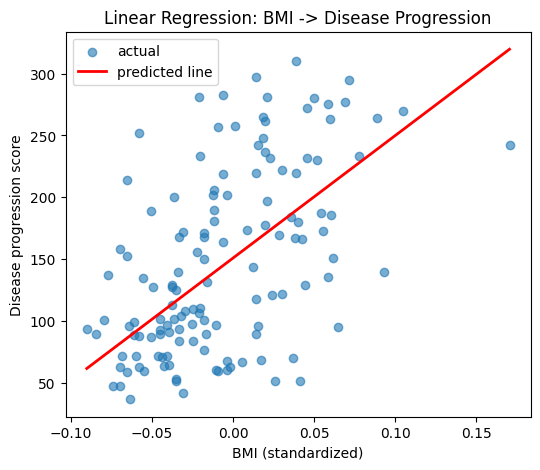

In [317]:
plt.figure(figsize=(6, 5))
plt.scatter(Xb_test, yb_test, alpha=0.6, label="actual")
order = np.argsort(Xb_test[:, 0])
plt.plot(Xb_test[order], predictions[order], color="red", linewidth=2, label="predicted line")
plt.title("Linear Regression: BMI -> Disease Progression")
plt.xlabel("BMI (standardized)")
plt.ylabel("Disease progression score")
plt.legend()
plt.show()

### 2. Ridge/Lasso 전에: 왜 스케일링이 필요할까? (diabetes, 특징 10개)

방금은 특징이 1개(bmi)뿐이라 스케일이 문제되지 않았습니다. 이번엔
**diabetes의 원본(스케일링 안 된) 10개 특징**을 그대로 써서 Ridge/Lasso를
돌려봅니다. `age`는 19~79 사이 값인데 `s5`는 3.26~6.11(로그 스케일) 같은
값이라 — 단위가 완전히 다른 특징들을 그대로 넣으면 어떻게 될까요?

In [318]:
diabetes_raw = load_diabetes(scaled=False)
X_diab_raw, y_diab_raw = diabetes_raw.data, diabetes_raw.target
print("Features:", diabetes_raw.feature_names)
for name, col in zip(diabetes_raw.feature_names, X_diab_raw.T):
    print(f"  {name}: {col.min():.2f} ~ {col.max():.2f}")

X_diab_train, X_diab_test, y_diab_train, y_diab_test = train_test_split(
    X_diab_raw, y_diab_raw, test_size=0.3, random_state=42
)

Features: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']
  age: 19.00 ~ 79.00
  sex: 1.00 ~ 2.00
  bmi: 18.00 ~ 42.20
  bp: 62.00 ~ 133.00
  s1: 97.00 ~ 301.00
  s2: 41.60 ~ 242.40
  s3: 22.00 ~ 99.00
  s4: 2.00 ~ 9.09
  s5: 3.26 ~ 6.11
  s6: 58.00 ~ 124.00


**스케일링 없이** Ridge/Lasso(둘 다 `alpha=10`, 정규화를 꽤 강하게 줘야
차이가 잘 보입니다)를 학습시켜봅니다.

In [319]:
ridge_unscaled = Ridge(alpha=10).fit(X_diab_train, y_diab_train)
lasso_unscaled = Lasso(alpha=10, max_iter=5000).fit(X_diab_train, y_diab_train)

r2_ridge_unscaled = r2_score(y_diab_test, ridge_unscaled.predict(X_diab_test))
r2_lasso_unscaled = r2_score(y_diab_test, lasso_unscaled.predict(X_diab_test))

print(f"[Ridge, unscaled]  R^2: {r2_ridge_unscaled:.3f}")
print(f"[Lasso, unscaled]  R^2: {r2_lasso_unscaled:.3f}")
print("Lasso 계수(스케일링 전):")
for name, coef in zip(diabetes_raw.feature_names, lasso_unscaled.coef_):
    print(f"  {name}: {coef:.3f}")

[Ridge, unscaled]  R^2: 0.464
[Lasso, unscaled]  R^2: 0.430
Lasso 계수(스케일링 전):
  age: 0.047
  sex: -0.000
  bmi: 6.437
  bp: 1.223
  s1: 0.778
  s2: -0.888
  s3: -1.822
  s4: 0.000
  s5: 0.000
  s6: 0.303


`sex`(1~2 사이 값인데 계수가 큼)와 `s5`(3~6 사이인데 역시 계수가 아주
큼) 같은, **값의 범위가 좁은 특징일수록 계수가 커지는** 패턴이 보일
겁니다 — 특징이 원래 실제로 얼마나 중요한지와는 무관하게, 그냥 단위가
작다는 이유만으로 계수가 커지는 것입니다. Lasso가 0으로 누르는 특징도
"진짜 안 중요한 특징"이 아니라 "마침 값의 범위가 큰 특징" 위주가 되기
쉽습니다. 이제 `StandardScaler`로 스케일링한 뒤 같은 `alpha=10`으로
다시 학습시켜봅니다.

In [320]:
scaler_diab = StandardScaler()
X_diab_train_scaled = scaler_diab.fit_transform(X_diab_train)
X_diab_test_scaled = scaler_diab.transform(X_diab_test)

ridge_scaled = Ridge(alpha=10).fit(X_diab_train_scaled, y_diab_train)
lasso_scaled = Lasso(alpha=10, max_iter=5000).fit(X_diab_train_scaled, y_diab_train)

r2_ridge_scaled = r2_score(y_diab_test, ridge_scaled.predict(X_diab_test_scaled))
r2_lasso_scaled = r2_score(y_diab_test, lasso_scaled.predict(X_diab_test_scaled))

print(f"[Ridge, scaled]  R^2: {r2_ridge_scaled:.3f}")
print(f"[Lasso, scaled]  R^2: {r2_lasso_scaled:.3f}")
print("Lasso 계수(스케일링 후):")
for name, coef in zip(diabetes_raw.feature_names, lasso_scaled.coef_):
    print(f"  {name}: {coef:.3f}")

[Ridge, scaled]  R^2: 0.478
[Lasso, scaled]  R^2: 0.458
Lasso 계수(스케일링 후):
  age: 0.000
  sex: -0.000
  bmi: 25.408
  bp: 9.563
  s1: -0.000
  s2: -0.000
  s3: -5.551
  s4: 0.000
  s5: 13.976
  s6: 0.000


,Model,R2
0,Ridge (unscaled),0.463731
1,Ridge (scaled),0.478079
2,Lasso (unscaled),0.429895
3,Lasso (scaled),0.458184


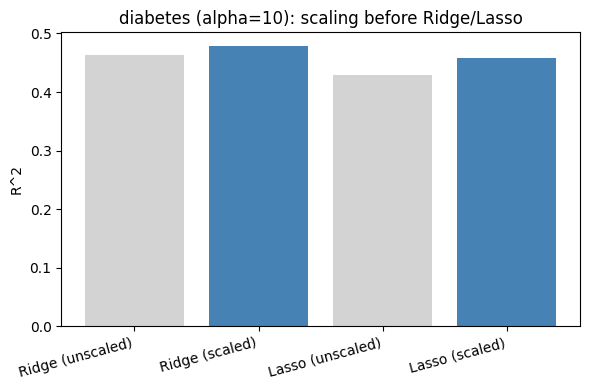

In [321]:
scaling_compare = pd.DataFrame([
    {"Model": "Ridge (unscaled)", "R2": r2_ridge_unscaled},
    {"Model": "Ridge (scaled)", "R2": r2_ridge_scaled},
    {"Model": "Lasso (unscaled)", "R2": r2_lasso_unscaled},
    {"Model": "Lasso (scaled)", "R2": r2_lasso_scaled},
])
display(scaling_compare)

plt.figure(figsize=(6, 4))
colors = ["lightgray", "steelblue", "lightgray", "steelblue"]
plt.bar(scaling_compare["Model"], scaling_compare["R2"], color=colors)
plt.title("diabetes (alpha=10): scaling before Ridge/Lasso")
plt.ylabel("R^2")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

### 3. Ridge / Lasso / RidgeCV / LassoCV — Mercedes-Benz Greener Manufacturing

diabetes 예제는 특징이 10개뿐이라 정규화가 크게 도움되지 않았죠. 이번엔
**Mercedes-Benz Greener Manufacturing** 데이터셋을 씁니다 — 자동차의
다양한 옵션 조합(익명화된 이진 특징 수백 개)으로 그 차가 테스트 벤치를
통과하는 데 걸리는 시간(`y`, 초 단위)을 예측하는 문제입니다.

특징 대부분이 `X10`, `X11`, ... 처럼 이름 붙은 **이진(0/1) 특징 수백
개**라, 서로 거의 똑같은(중복되거나 상수인) 특징이 많습니다 — Lasso가
이런 특징들을 골라내는 걸 보기에 좋은 예시입니다.

In [322]:
!pip install -q kagglehub
import kagglehub
import glob

mb_dir = kagglehub.dataset_download("yasserh/mercedesbenz-greener-manufacturing-dataset")
csv_candidates = glob.glob(f"{mb_dir}/**/*train*.csv", recursive=True) or \
                 glob.glob(f"{mb_dir}/**/*.csv", recursive=True)
csv_path = csv_candidates[0]
print("Using file:", csv_path)

df_mb = pd.read_csv(csv_path)
print("Shape:", df_mb.shape)
df_mb.head()

100%|██████████| 564k/564k [00:00<00:00, 27.2MB/s]

Extracting files...
Using file: /root/.cache/kagglehub/datasets/yasserh/mercedesbenz-greener-manufacturing-dataset/versions/1/train.csv


Shape: (4209, 378)


,ID,y,X0,X1,X2,X3,X4,X5,X6,X8,...,X375,X376,X377,X378,X379,X380,X382,X383,X384,X385
0,0,130.81,k,v,at,a,d,u,j,o,...,0,0,1,0,0,0,0,0,0,0
1,6,88.53,k,t,av,e,d,y,l,o,...,1,0,0,0,0,0,0,0,0,0
2,7,76.26,az,w,n,c,d,x,j,x,...,0,0,0,0,0,0,1,0,0,0
3,9,80.62,az,t,n,f,d,x,l,e,...,0,0,0,0,0,0,0,0,0,0
4,13,78.02,az,v,n,f,d,h,d,n,...,0,0,0,0,0,0,0,0,0,0


In [323]:
TARGET_CANDIDATES = ["y", "time", "target"]
TARGET = next(c for c in TARGET_CANDIDATES if c in df_mb.columns)
print("Target column:", TARGET)

# 숫자형(대부분 0/1) 특징만 입력으로 씁니다 -- 범주형 텍스트 열(X0~X8 같은)의
# 인코딩은 이번 주 범위 밖이라 제외합니다 (Week 6에서 다룹니다). ID 열과
# 분산이 0인(모든 값이 같은) 특징도 제외합니다.
X_mb = df_mb.select_dtypes(include=[np.number]).drop(columns=[TARGET, "ID"], errors="ignore")
X_mb = X_mb.loc[:, X_mb.std() > 0]
y_mb = df_mb[TARGET]

print("Features:", X_mb.shape[1])
print("Shape:", X_mb.shape)

Target column: y
Features: 356
Shape: (4209, 356)


In [324]:
X_mb_train, X_mb_test, y_mb_train, y_mb_test = train_test_split(
    X_mb, y_mb, test_size=0.3, random_state=42
)
print("Train:", X_mb_train.shape, "Test:", X_mb_test.shape)

Train: (2946, 356) Test: (1263, 356)


#### 특징 스케일링

Ridge/Lasso는 계수 크기에 페널티를 매기므로, 특징들의 스케일이 다르면
정규화가 공정하게 적용되지 않습니다. 이 데이터는 특징 대부분이 이미 0/1
이진값이라 스케일이 비슷하지만, 일관성을 위해 `StandardScaler`로 평균 0,
표준편차 1로 맞춘 뒤 사용합니다 (학습 데이터에만 `fit`).

In [325]:
scaler_mb = StandardScaler()
X_mb_train_scaled = scaler_mb.fit_transform(X_mb_train)
X_mb_test_scaled = scaler_mb.transform(X_mb_test)

#### (1) Linear Regression — 기준선

대표적인 인자:

- **`fit_intercept`** (기본값 `True`) — 절편을 포함할지 여부.
- **`positive`** (기본값 `False`) — `True`면 모든 계수를 양수로 제한.
- **`n_jobs`** (기본값 `None`) — 계산에 사용할 CPU 코어 수.

정규화 없는 기본 선형회귀입니다. 서로 거의 똑같은 이진 특징이 수백 개나
있으면 계수가 불안정해지기 쉽습니다 — 이 결과를 기준(baseline)으로 삼아
Ridge/Lasso가 얼마나 도움이 되는지 비교합니다.

In [326]:
lr_mb = LinearRegression()
lr_mb.fit(X_mb_train_scaled, y_mb_train)
preds_lr_mb = lr_mb.predict(X_mb_test_scaled)

print(f"[Linear Regression] R^2:  {r2_score(y_mb_test, preds_lr_mb):.3f}")
print(f"[Linear Regression] RMSE: {mean_squared_error(y_mb_test, preds_lr_mb) ** 0.5:.3f}")

[Linear Regression] R^2:  0.444
[Linear Regression] RMSE: 9.968


#### (2) Ridge Regression — L2 정규화

대표적인 인자:

- **`alpha`** (기본값 `1.0`) — 계수 크기에 대한 페널티 강도. 클수록
  계수들이 0 쪽으로 눌려서 모델이 단순해지고 과적합이 줄지만, 너무 크면
  과소적합이 됩니다. 보통 `0.01, 0.1, 1.0, 10.0, 100.0`처럼 로그 스케일로
  후보를 고릅니다.
- **`solver`** (기본값 `'auto'`) — 계수를 계산하는 방법. 후보:
  `'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'`.
- **`max_iter`** (기본값 `None`) — 반복적인 solver를 쓸 때 최대 반복 횟수.

지금은 `alpha=1.0`(기본값)을 그대로 써봅니다.

In [327]:
ridge_mb = Ridge(alpha=1.0)
ridge_mb.fit(X_mb_train_scaled, y_mb_train)
preds_ridge_mb = ridge_mb.predict(X_mb_test_scaled)

print(f"[Ridge, alpha=1.0] R^2:  {r2_score(y_mb_test, preds_ridge_mb):.3f}")
print(f"[Ridge, alpha=1.0] RMSE: {mean_squared_error(y_mb_test, preds_ridge_mb) ** 0.5:.3f}")

[Ridge, alpha=1.0] R^2:  0.444
[Ridge, alpha=1.0] RMSE: 9.967


#### (3) Lasso Regression — L1 정규화

대표적인 인자:

- **`alpha`** (기본값 `1.0`) — Ridge와 같은 역할이지만, L1 페널티는 덜
  중요한 특징의 계수를 아예 **0으로** 만듭니다 — 자동 특징 선택 효과.
  Lasso는 alpha가 조금만 커져도 계수가 급격히 0이 되는 경우가 많아서
  보통 `0.001, 0.01, 0.1, 1.0`처럼 더 작은 값부터 후보를 고릅니다.
- **`max_iter`** (기본값 `1000`) — 좌표하강법 반복의 최대 횟수. 특징이
  수백 개나 되면 기본값으로는 수렴 전에 반복이 끝날 수 있어 늘려줍니다.
- **`selection`** (기본값 `'cyclic'`) — 계수를 업데이트할 순서. 후보:
  `'cyclic'`, `'random'`.

서로 거의 똑같은 이진 특징이 많은 이 데이터에서, Lasso가 그중 상당수의
계수를 실제로 0으로 만드는지 확인해봅니다.

In [ ]:
lasso_mb = Lasso(alpha=0.1, max_iter=50000)
lasso_mb.fit(X_mb_train_scaled, y_mb_train)
preds_lasso_mb = lasso_mb.predict(X_mb_test_scaled)
n_zero_lasso_mb = int((lasso_mb.coef_ == 0).sum())

print(f"[Lasso, alpha=0.1] R^2:  {r2_score(y_mb_test, preds_lasso_mb):.3f}")
print(f"[Lasso, alpha=0.1] RMSE: {mean_squared_error(y_mb_test, preds_lasso_mb) ** 0.5:.3f}")
print(f"0으로 눌린 계수 개수: {n_zero_lasso_mb} / {len(lasso_mb.coef_)}")

#### alpha, 매번 손으로 골라야 할까?

방금까지는 `alpha`를 하나 정해서(`1.0`, `0.1`) 넣어봤습니다. 어떤 값이
가장 좋은지는 미리 알 수 없으니, 여러 후보를 다 시도해보고 검증 성능이
가장 좋은 걸 고르는 게 최선입니다. **`RidgeCV`/`LassoCV`**는 이 과정(여러
alpha 후보 × 교차검증)을 자동으로 해주는 버전입니다.

#### (4) RidgeCV

대표적인 인자:

- **`alphas`** (기본값 `(0.1, 1.0, 10.0)`) — 시도해볼 alpha 후보 리스트.
  특징이 수백 개라 후보 하나당 학습이 오래 걸릴 수 있으므로
  `[0.1, 1, 10, 100]`으로 후보를 줄여서 실습합니다.
- **`cv`** (기본값 `None`) — `None`이면 효율적인 **Leave-One-Out**
  교차검증을 사용합니다. 정수(예: `cv=5`)를 주면 일반 k-fold로 바뀝니다.
- **`scoring`** (기본값 `None`) — 각 alpha를 평가할 지표. `None`이면 R².

학습이 끝나면 `.alpha_`에 선택된 최적 alpha가 저장됩니다.

In [335]:
ridge_cv_mb = RidgeCV(np.logspace(-3,3,7), cv=5)
ridge_cv_mb.fit(X_mb_train_scaled, y_mb_train)
preds_ridge_cv_mb = ridge_cv_mb.predict(X_mb_test_scaled)

print(f"[RidgeCV] selected alpha: {ridge_cv_mb.alpha_:.4f}")
print(f"[RidgeCV] R^2:  {r2_score(y_mb_test, preds_ridge_cv_mb):.3f}")
print(f"[RidgeCV] RMSE: {mean_squared_error(y_mb_test, preds_ridge_cv_mb) ** 0.5:.3f}")

[RidgeCV] selected alpha: 1000.0000
[RidgeCV] R^2:  0.455
[RidgeCV] RMSE: 9.870


#### (5) LassoCV

대표적인 인자:

- **`alphas`** (기본값 `100`) — 정수를 주면 그 개수만큼 alpha 후보를
  자동으로 생성합니다. 특징이 수백 개라 후보 하나당 학습이 오래 걸리므로
  RidgeCV와 같은 `[0.1, 1, 10, 100]`으로 직접 지정합니다.
- **`cv`** (기본값 `None`) — `None`이면 **5-fold** 교차검증 (RidgeCV의
  `None`과 의미가 다릅니다!).
- **`eps`** (기본값 `0.001`) — 후보 alpha의 최소/최대 비율.
- **`n_jobs`** (기본값 `None`) — 병렬 처리에 사용할 CPU 코어 수. `-1`이면
  가능한 모든 코어를 사용합니다.

역시 `.alpha_`에 선택된 최적 alpha가 저장됩니다.

In [ ]:
lasso_cv_mb = LassoCV(alphas=np.logspace(-3,3,7), cv=5, random_state=42, n_jobs=-1, max_iter=50000)
lasso_cv_mb.fit(X_mb_train_scaled, y_mb_train)
preds_lasso_cv_mb = lasso_cv_mb.predict(X_mb_test_scaled)
n_zero_lasso_cv_mb = int((lasso_cv_mb.coef_ == 0).sum())

print(f"[LassoCV] selected alpha: {lasso_cv_mb.alpha_:.4f}")
print(f"[LassoCV] R^2:  {r2_score(y_mb_test, preds_lasso_cv_mb):.3f}")
print(f"[LassoCV] RMSE: {mean_squared_error(y_mb_test, preds_lasso_cv_mb) ** 0.5:.3f}")
print(f"0으로 눌린 계수 개수: {n_zero_lasso_cv_mb} / {len(lasso_cv_mb.coef_)}")

#### 다섯 모델 비교

정규화가 없을 때(LinearRegression), alpha를 손으로 고정했을 때(Ridge/
Lasso), 자동으로 탐색했을 때(RidgeCV/LassoCV)의 테스트 R²를 한눈에
비교합니다. 서로 거의 중복되는 이진 특징이 많은 이 데이터에서는 Lasso
계열이 불필요한 특징을 걸러내면서 확실한 차이를 보여줄 가능성이
높습니다.

In [ ]:
mb_results = pd.DataFrame([
    {"Model": "Linear Regression", "alpha": "-",
     "R2": r2_score(y_mb_test, preds_lr_mb), "RMSE": mean_squared_error(y_mb_test, preds_lr_mb) ** 0.5},
    {"Model": "Ridge (fixed alpha)", "alpha": 1.0,
     "R2": r2_score(y_mb_test, preds_ridge_mb), "RMSE": mean_squared_error(y_mb_test, preds_ridge_mb) ** 0.5},
    {"Model": "Lasso (fixed alpha)", "alpha": 0.1,
     "R2": r2_score(y_mb_test, preds_lasso_mb), "RMSE": mean_squared_error(y_mb_test, preds_lasso_mb) ** 0.5},
    {"Model": "RidgeCV", "alpha": round(ridge_cv_mb.alpha_, 4),
     "R2": r2_score(y_mb_test, preds_ridge_cv_mb), "RMSE": mean_squared_error(y_mb_test, preds_ridge_cv_mb) ** 0.5},
    {"Model": "LassoCV", "alpha": round(lasso_cv_mb.alpha_, 4),
     "R2": r2_score(y_mb_test, preds_lasso_cv_mb), "RMSE": mean_squared_error(y_mb_test, preds_lasso_cv_mb) ** 0.5},
])
display(mb_results)

plt.figure(figsize=(7, 4))
plt.bar(mb_results["Model"], mb_results["R2"], color="steelblue")
plt.title("Mercedes-Benz Greener Manufacturing: R^2 by Model")
plt.ylabel("R^2")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

## Try it yourself

1. **Compare k-NN to a "dumb" baseline.** For Breast Cancer, what accuracy
   would you get by always predicting the majority class? Is k-NN actually
   learning something?
2. **Compare to a "dumb" baseline.** What R² would you get if you always
   predicted the *average* disease progression, regardless of BMI? (Hint:
   that's what an R² of 0 means.)
3. **Add a second feature to the regression.** Use both `bmi` and `s5`
   (another column in `diabetes.feature_names`) as inputs to
   `LinearRegression` — does the R² improve? 아래 셀에 두 특징을 합쳐서
   학습/테스트 데이터를 준비하는 코드를 미리 작성해뒀습니다 — 이어서
   `LinearRegression`으로 학습시키고 R²를 계산해서 비교해보세요.

In [332]:
# bmi와 s5, 두 특징을 하나의 입력 데이터로 합칩니다
s5 = diabetes.data[:, diabetes.feature_names.index("s5")].reshape(-1, 1)
X_two = np.hstack([bmi, s5])  # (442, 1)짜리 두 배열을 옆으로 이어붙여 (442, 2) 데이터를 만듭니다

Xb2_train, Xb2_test, yb2_train, yb2_test = train_test_split(
    X_two, target, test_size=0.3, random_state=42
)

# TODO: 위에서 나눈 Xb2_train/yb2_train으로 LinearRegression을 학습시키고,
# Xb2_test에 대한 예측의 R² 점수를 계산해서 위 bmi 단일 특징 모델과 비교해보세요.


---
## 🎯 캡스톤: 이번 학기 성적 위험도 예측기

가상의 선배 150명의 "주당 공부시간 / 출석률 / 평균 수면시간 -> 기말 점수" 기록을 드립니다. 이 데이터로 **k-NN 분류기**(위험군 Safe/Warning/Danger 예측)와 **선형회귀**(예상 점수 예측)를 직접 만들어보고, 마지막엔 **여러분 자신의 예상 습관**을 입력해서 결과를 확인해보세요.

**확장 아이디어:** 학기 말에 실제 본인의 공부시간/출석/수면 기록과 실제 성적을 몇 학기치 모아서 `students_df`를 바꿔치기하면, 진짜 "내 성적 예측기"가 됩니다.

In [333]:
# 더미 데이터 생성 (실행만 하면 됩니다)
import pandas as pd
rng = np.random.default_rng(7)
n_students = 150

weekly_study_hours = np.clip(rng.normal(10, 4, n_students), 0, 25)
attendance_rate = np.clip(rng.normal(0.85, 0.12, n_students), 0.4, 1.0)
sleep_hours_avg = np.clip(rng.normal(6.5, 1.2, n_students), 3, 10)

final_score = (
    20
    + 2.2 * weekly_study_hours
    + 45 * attendance_rate
    + 1.5 * sleep_hours_avg
    + rng.normal(0, 6, n_students)
)
final_score = np.clip(final_score, 0, 100)

def to_risk(score):
    if score >= 80:
        return "Safe"
    elif score >= 60:
        return "Warning"
    return "Danger"

students_df = pd.DataFrame({
    "weekly_study_hours": weekly_study_hours.round(1),
    "attendance_rate": attendance_rate.round(2),
    "sleep_hours_avg": sleep_hours_avg.round(1),
    "final_score": final_score.round(1),
})
students_df["risk"] = students_df["final_score"].apply(to_risk)
students_df.head()

,weekly_study_hours,attendance_rate,sleep_hours_avg,final_score,risk
0,10.0,0.77,8.3,88.1,Safe
1,11.2,0.81,7.2,95.5,Safe
2,8.9,0.78,6.4,84.2,Safe
3,6.4,0.85,5.8,74.6,Warning
4,8.2,0.80,5.7,82.2,Safe


### 여러분의 과제

1. `students_df`에서 `weekly_study_hours`, `attendance_rate`, `sleep_hours_avg` 3개를 입력(X)으로, `risk`를 정답(y)으로 하여 **k-NN 분류기**를 학습시키고 테스트 정확도를 출력하세요. (Part A 코드를 참고하세요: `train_test_split`, `KNeighborsClassifier`, `accuracy_score`)
2. 같은 3개 입력으로 `final_score`(숫자)를 예측하는 **선형회귀 모델**을 학습시키고 R² 점수를 출력하세요. (Part B 코드 참고: `LinearRegression`, `r2_score`)
3. 아래에 **여러분 자신의 예상 습관**(예상 주당 공부시간, 예상 출석률, 예상 평균 수면시간)을 숫자로 입력하고, 학습된 두 모델로 (a) 위험군과 (b) 예상 점수를 각각 예측해서 출력해보세요.

In [334]:
# TODO 1: k-NN 분류기로 risk(Safe/Warning/Danger)를 예측하는 모델을 학습하고 테스트 정확도를 출력하세요.


# TODO 2: 선형회귀로 final_score를 예측하는 모델을 학습하고 R^2를 출력하세요.


# TODO 3: 나의 예상 습관을 입력하고, 위 두 모델로 위험군과 예상 점수를 예측해보세요.
my_weekly_study_hours = None   # 예: 8
my_attendance_rate = None      # 예: 0.9
my_sleep_hours_avg = None      # 예: 6.5